# JOCELYNE GONZÁLEZ HERNÁNDEZ
## 225369-5

### EJERCICIO 1


In [123]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.gridspec as gridspec
from collections import Counter
from sklearn import metrics
import numpy as np
from matplotlib.colors import LogNorm
from sklearn.metrics import f1_score
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import f1_score

In [124]:
df = pd.read_csv('country_data.csv')
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200
...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310


In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [126]:
print("Número de variables:", len(df.columns))
print("Longitud del conjunto de datos:", len(df))

Número de variables: 10
Longitud del conjunto de datos: 167


## verificar si hay datos faltantes

In [127]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


<Axes: >

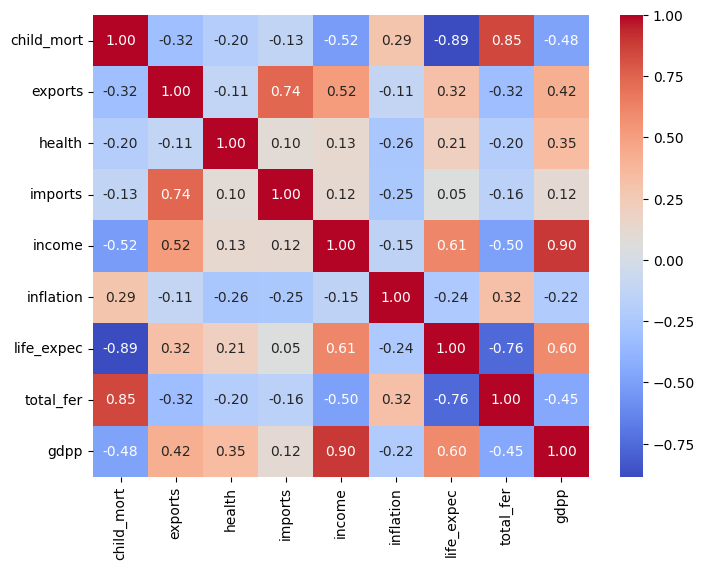

In [128]:
correlation_matrix = df.drop('country', axis=1).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

In [129]:
#Estandarizar variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop('country', axis=1))
df_scaled

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]])

<Axes: >

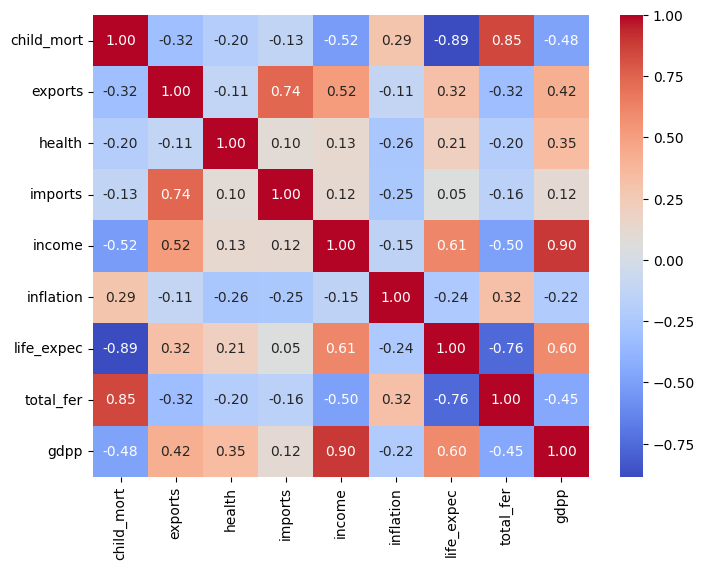

In [130]:
correlation_matrix = df.drop('country', axis=1).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

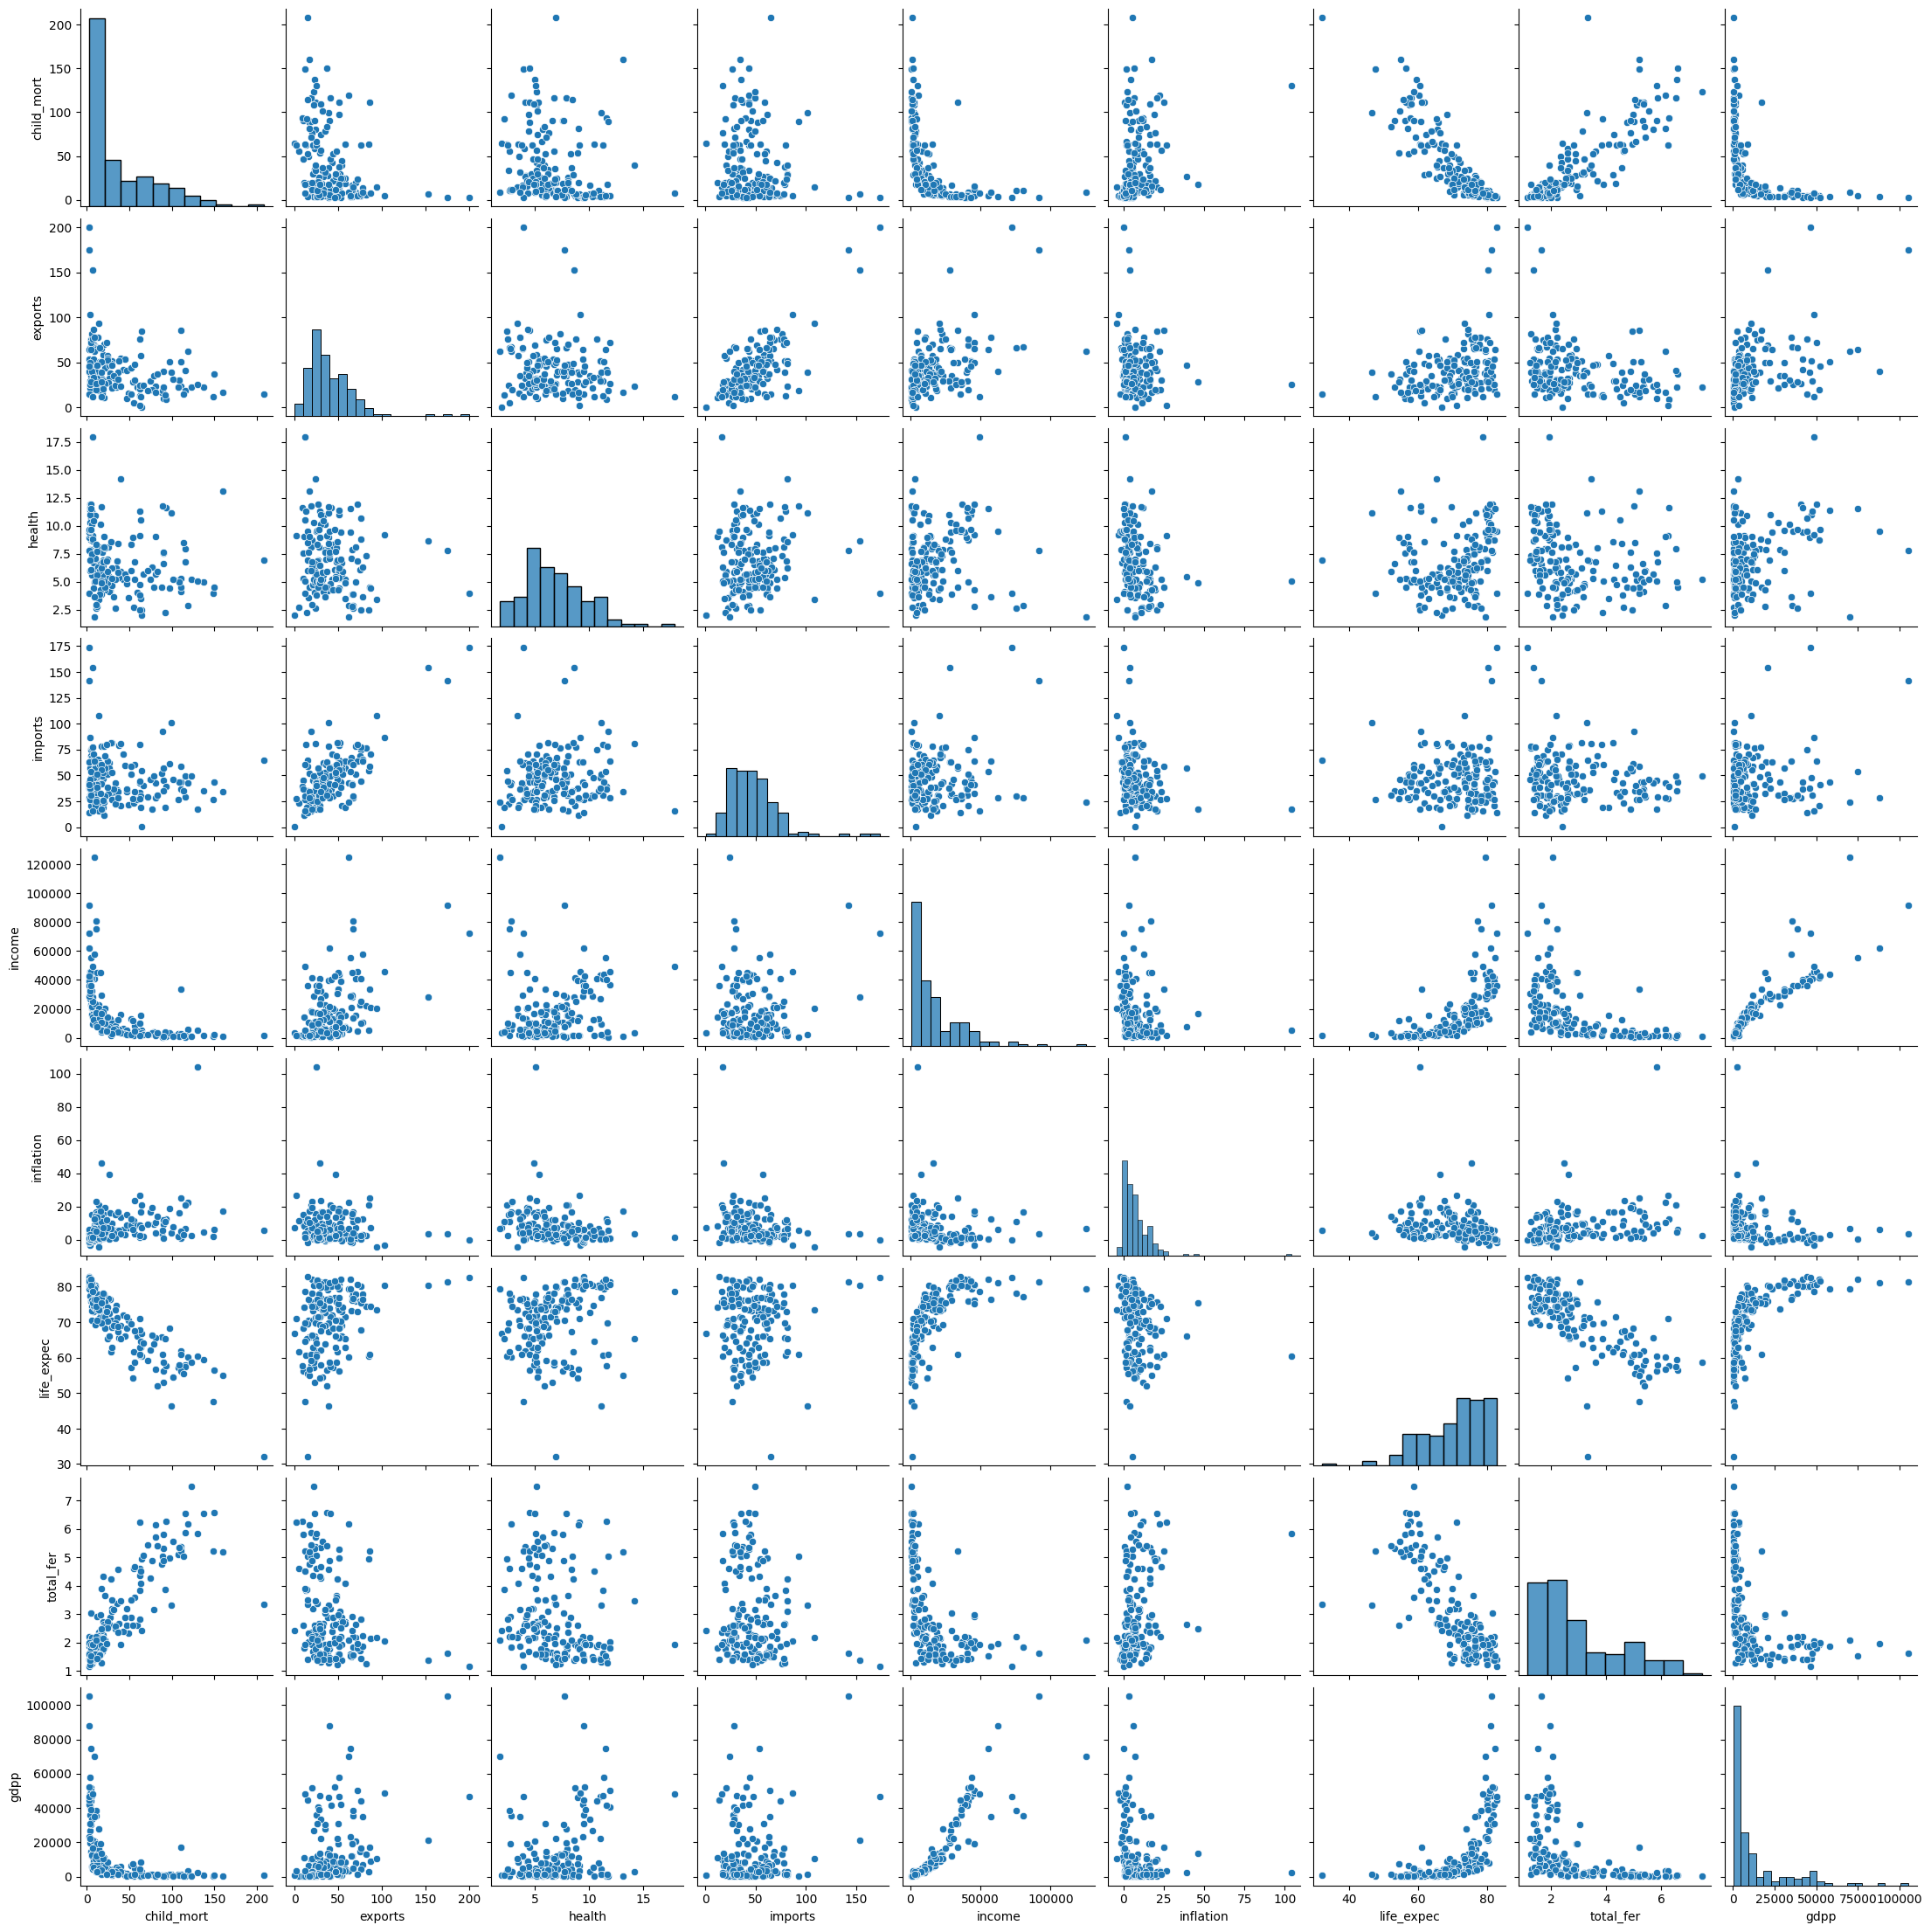

In [131]:
#Pair plot
sns.pairplot(df.drop('country', axis=1))

## Análisis de componentes principales

In [132]:
from sklearn.decomposition import PCA

# Elección arbitraria de dimensión
pca = PCA(n_components=3)  #n_componentes -> a cuantas dimensiones voy a proyectar
X_reduced = pca.fit_transform(df_scaled) #transformación
X_reduced = pd.DataFrame(X_reduced, columns=["c1", "c2", "c2"])  #solo dos variables
X_reduced

,c1,c2,c2
0,-2.913025,0.095621,-0.718118
1,0.429911,-0.588156,-0.333486
2,-0.285225,-0.455174,1.221505
3,-2.932423,1.695555,1.525044
4,1.033576,0.136659,-0.225721
...,...,...,...
162,-0.820631,0.639570,-0.389923
163,-0.551036,-1.233886,3.101350
164,0.498524,1.390744,-0.238526
165,-1.887451,-0.109453,1.109752


In [133]:
# qué porcentaje de la variabilidad se capturo.
# Lo más grande es 1
pca.explained_variance_ratio_

array([0.4595174 , 0.17181626, 0.13004259])

In [135]:
# Podemos 'proyectar todas' y decidir el punto de corte con un diagrama de Pareto
pca = PCA(n_components=9)
X_reduced = pca.fit_transform(df_scaled)
varianza = pca.explained_variance_ratio_
varianza

array([0.4595174 , 0.17181626, 0.13004259, 0.11053162, 0.07340211,
       0.02484235, 0.0126043 , 0.00981282, 0.00743056])

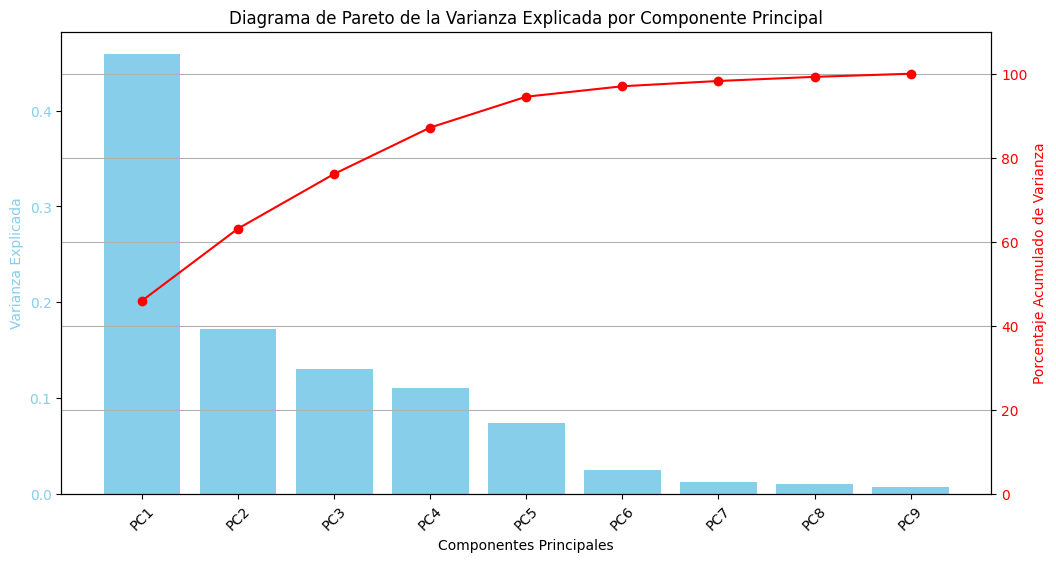

In [136]:
explained_variance_series = pd.Series(varianza, index=[f'PC{i+1}' for i in range(len(varianza))])

# Calculate cumulative percentage
cumulative_percentage = explained_variance_series.cumsum() / explained_variance_series.sum() * 100

# Create Pareto chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for explained variance
ax1.bar(explained_variance_series.index, explained_variance_series.values, color='skyblue')
ax1.set_ylabel('Varianza Explicada', color='skyblue') # Corrected 'skyblu3e' to 'skyblue'
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xlabel('Componentes Principales')
plt.xticks(rotation=45)

# Line plot for cumulative percentage
ax2 = ax1.twinx()
ax2.plot(explained_variance_series.index, cumulative_percentage, color='red', marker='o', linestyle='-')
ax2.set_ylabel('Porcentaje Acumulado de Varianza', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(0, 110)

# Add title and grid
plt.title('Diagrama de Pareto de la Varianza Explicada por Componente Principal')
plt.grid(True)

# Show plot
plt.show()

Con 3 componentes principales (PC1, PC2 y PC3) se captura más del 60% de la varianza total. Esto representa una mejora significativa en la retención de información comparado con 2 componentes, pues este acumula una varianza de menos del 40%. 3 componentes te permite conservar una mayor parte de la estructura original de tus datos, aunque es más ácil grafica en 2D

In [137]:
pca_components = pd.DataFrame(pca.components_, columns=df.drop('country', axis=1).columns, index=[f'c{i+1}' for i in range(pca.n_components_)])
print("Importancia de las variables en los componentes principales:")
print(pca_components)

Importancia de las variables en los componentes principales:
    child_mort   exports    health   imports    income  inflation  life_expec  \
c1   -0.419519  0.283897  0.150838  0.161482  0.398441  -0.193173    0.425839   
c2    0.192884  0.613163 -0.243087  0.671821  0.022536  -0.008404   -0.222707   
c3   -0.029544  0.144761 -0.596632 -0.299927  0.301548   0.642520    0.113919   
c4    0.370653  0.003091  0.461897 -0.071907  0.392159   0.150442   -0.203797   
c5   -0.168970  0.057616  0.518000  0.255376 -0.247150   0.714869    0.108220   
c6   -0.200628  0.059333 -0.007276  0.030032 -0.160347  -0.066285    0.601127   
c7    0.079489  0.707303  0.249831 -0.592190 -0.095562  -0.104633   -0.018486   
c8    0.682743  0.014197 -0.072497  0.028946 -0.352624   0.011538    0.504664   
c9   -0.327542  0.123082 -0.113088 -0.099037 -0.612982   0.025236   -0.294040   

    total_fer      gdpp  
c1  -0.403729  0.392645  
c2   0.155233 -0.046022  
c3   0.019549  0.122977  
c4   0.378304  0.531995 

In [138]:
X = df_scaled
X

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]])

In [139]:
#Contar elementos unicos de la variable country
unique_elements, counts = np.unique(df['country'], return_counts=True)
print(f"Elementos únicos y su recuento:\n{unique_elements}\n{counts}")
#Suma de los elementos unicos
print(f"Suma de los elementos únicos: {np.sum(counts)}")
#

Elementos únicos y su recuento:
['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas'
 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin'
 'Bhutan' 'Bolivia' 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'Brunei'
 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada'
 'Cape Verde' 'Central African Republic' 'Chad' 'Chile' 'China' 'Colombia'
 'Comoros' 'Congo, Dem. Rep.' 'Congo, Rep.' 'Costa Rica' "Cote d'Ivoire"
 'Croatia' 'Cyprus' 'Czech Republic' 'Denmark' 'Dominican Republic'
 'Ecuador' 'Egypt' 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia'
 'Fiji' 'Finland' 'France' 'Gabon' 'Gambia' 'Georgia' 'Germany' 'Ghana'
 'Greece' 'Grenada' 'Guatemala' 'Guinea' 'Guinea-Bissau' 'Guyana' 'Haiti'
 'Hungary' 'Iceland' 'India' 'Indonesia' 'Iran' 'Iraq' 'Ireland' 'Israel'
 'Italy' 'Jamaica' 'Japan' 'Jordan' 'Kazakhstan' 'Kenya' 'Kiribati'
 'Kuwait' 'Kyrgyz Republic' 'Lao' 'Latvia' 

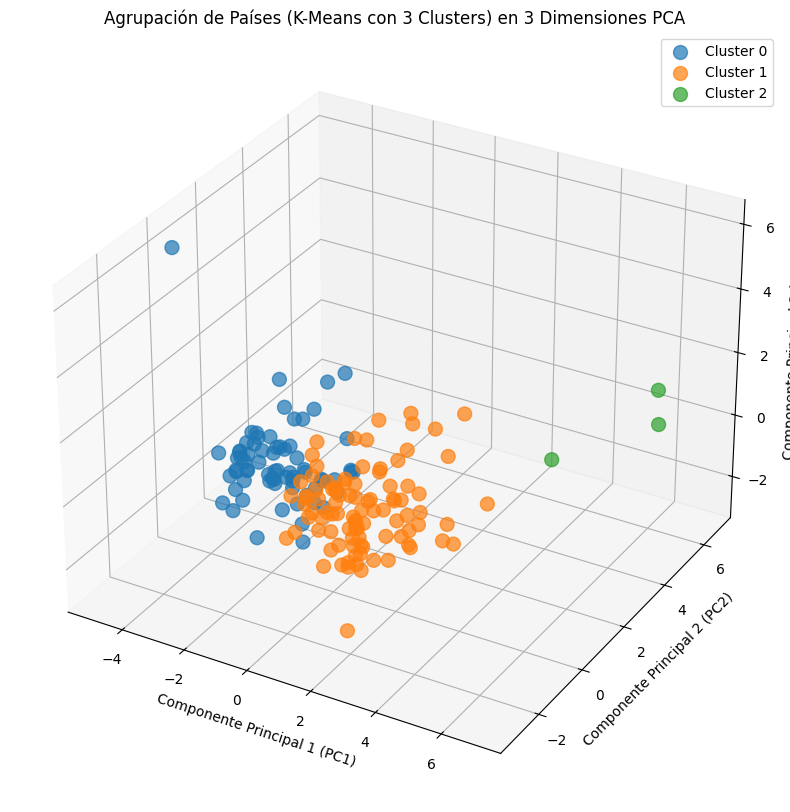

In [140]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Re-apply PCA with 3 components for clustering and plotting
pca_3_components = PCA(n_components=3)
X_reduced_for_clustering = pca_3_components.fit_transform(df_scaled)
X_reduced_for_clustering = pd.DataFrame(X_reduced_for_clustering, columns=["c1", "c2", "c3"])

# Assuming 3 clusters for demonstration
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_reduced_for_clustering)

# Add cluster labels to X_reduced_for_clustering for plotting
X_reduced_for_clustering['cluster'] = clusters

# Create the 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot each cluster separately to get distinct colors
for cluster_id in sorted(X_reduced_for_clustering['cluster'].unique()):
    subset = X_reduced_for_clustering[X_reduced_for_clustering['cluster'] == cluster_id]
    ax.scatter(
        subset['c1'], subset['c2'], subset['c3'],
        label=f'Cluster {cluster_id}',
        s=100, alpha=0.7
    )

ax.set_title(f'Agrupación de Países (K-Means con {k} Clusters) en 3 Dimensiones PCA')
ax.set_xlabel('Componente Principal 1 (PC1)')
ax.set_ylabel('Componente Principal 2 (PC2)')
ax.set_zlabel('Componente Principal 3 (PC3)')
ax.legend()
plt.grid(True)
plt.show()

In [141]:
#Haz con factoruize los country
df['country_factorized'] = pd.factorize(df['country'])[0]
df

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,country_factorized
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,3
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,4
...,...,...,...,...,...,...,...,...,...,...,...
162,Vanuatu,29.2,46.6,5.25,52.7,2950,2.62,63.0,3.50,2970,162
163,Venezuela,17.1,28.5,4.91,17.6,16500,45.90,75.4,2.47,13500,163
164,Vietnam,23.3,72.0,6.84,80.2,4490,12.10,73.1,1.95,1310,164
165,Yemen,56.3,30.0,5.18,34.4,4480,23.60,67.5,4.67,1310,165


In [143]:
#Estandarizar variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df = scaler.fit_transform(df.drop('country', axis=1))
df

array([[ 1.29153238, -1.13827979,  0.27908825, ...,  1.90288227,
        -0.67917961, -1.72171011],
       [-0.5389489 , -0.47965843, -0.09701618, ..., -0.85997281,
        -0.48562324, -1.70096662],
       [-0.27283273, -0.09912164, -0.96607302, ..., -0.0384044 ,
        -0.46537561, -1.68022312],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ..., -0.66120626,
        -0.63775406,  1.68022312],
       [ 0.44841668, -0.40647827, -0.59727159, ...,  1.14094382,
        -0.63775406,  1.70096662],
       [ 1.11495062, -0.15034774, -0.33801514, ...,  1.6246091 ,
        -0.62954556,  1.72171011]])

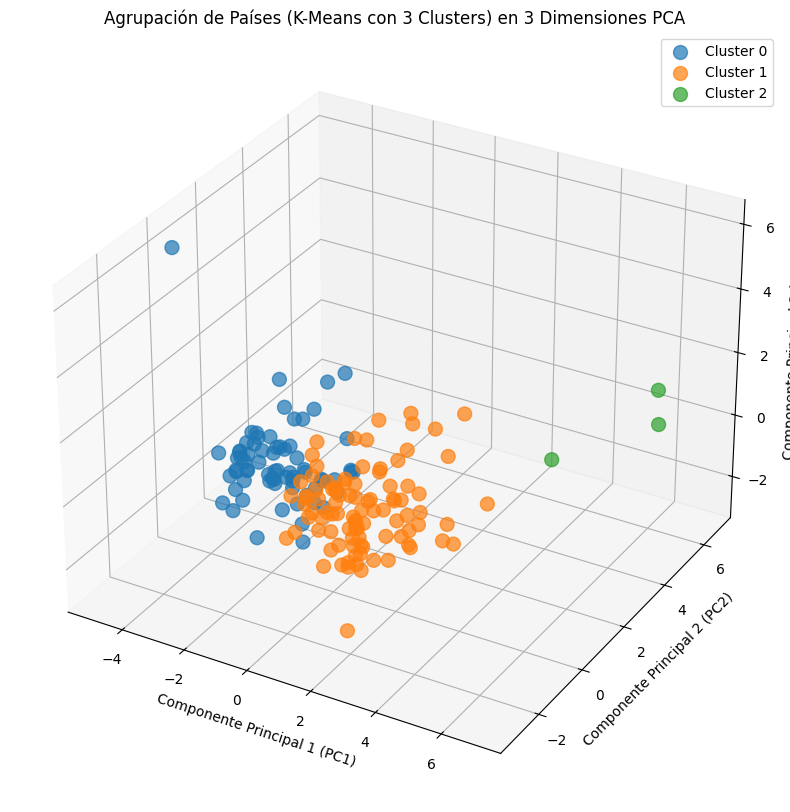

In [144]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

pca_3_components = PCA(n_components=3)
X_reduced_for_clustering = pca_3_components.fit_transform(df_scaled)
X_reduced_for_clustering = pd.DataFrame(X_reduced_for_clustering, columns=["c1", "c2", "c3"])

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_reduced_for_clustering)

X_reduced_for_clustering['cluster'] = clusters

# Create the 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot each cluster separately to get distinct colors
for cluster_id in sorted(X_reduced_for_clustering['cluster'].unique()):
    subset = X_reduced_for_clustering[X_reduced_for_clustering['cluster'] == cluster_id]
    ax.scatter(
        subset['c1'], subset['c2'], subset['c3'],
        label=f'Cluster {cluster_id}',
        s=100, alpha=0.7
    )

ax.set_title(f'Agrupación de Países (K-Means con {k} Clusters) en 3 Dimensiones PCA')
ax.set_xlabel('Componente Principal 1 (PC1)')
ax.set_ylabel('Componente Principal 2 (PC2)')
ax.set_zlabel('Componente Principal 3 (PC3)')
ax.legend()
plt.grid(True)
plt.show()

- Escogi la tecnica de agrupamiento K-means, ya que es el mpas sencillo y popular, me pareció suficiente que utilizara la distancia euclidia y no la densidad. Además de que un paso previo importante es escalar los datos y usar PCA. Cosa que ya se pedía en el ejercicio.
- Escogí 3 CLusters ya que es el que me daba Un Shiloutte menos bajo o cercano a 1

In [145]:
# Calculamos el coeficiente de Silhoutte  ---> KMEANS
print("Shiloutte: ", metrics.silhouette_score(X_reduced_for_clustering[['c1', 'c2', 'c3']], clusters, sample_size=10000))

Shiloutte:  0.3724161232764183


In [146]:
df_original = pd.read_csv('country_data.csv')
df_original['country_factorized'] = pd.factorize(df_original['country'])[0]
df_original['cluster'] = clusters
df_original.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,country_factorized,cluster
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,2,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,3,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,4,1


In [147]:
for cluster_id in sorted(df_original['cluster'].unique()):
    countries_in_cluster = df_original[df_original['cluster'] == cluster_id]['country'].tolist()
    print(f"\nCluster {cluster_id}:")
    print(countries_in_cluster)


Cluster 0:
['Afghanistan', 'Angola', 'Bangladesh', 'Benin', 'Bolivia', 'Botswana', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', "Cote d'Ivoire", 'Egypt', 'Equatorial Guinea', 'Eritrea', 'Fiji', 'Gabon', 'Gambia', 'Ghana', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'India', 'Indonesia', 'Iraq', 'Kenya', 'Kiribati', 'Kyrgyz Republic', 'Lao', 'Lesotho', 'Liberia', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mongolia', 'Mozambique', 'Myanmar', 'Namibia', 'Nepal', 'Niger', 'Nigeria', 'Pakistan', 'Philippines', 'Rwanda', 'Samoa', 'Senegal', 'Sierra Leone', 'Solomon Islands', 'South Africa', 'Sri Lanka', 'Sudan', 'Tajikistan', 'Tanzania', 'Timor-Leste', 'Togo', 'Tonga', 'Turkmenistan', 'Uganda', 'Uzbekistan', 'Vanuatu', 'Venezuela', 'Yemen', 'Zambia']

Cluster 1:
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahra

In [148]:
colombia_cluster = df_original[df_original['country'] == 'Colombia']['cluster'].iloc[0]
similar_countries = df_original[df_original['cluster'] == colombia_cluster]['country'].tolist()

print(f"Colombia pertenece al Cluster {colombia_cluster}.")
print(f"Los países con datos macroeconómicos similares a Colombia (en el mismo cluster) son:")
print(similar_countries)

Colombia pertenece al Cluster 1.
Los países con datos macroeconómicos similares a Colombia (en el mismo cluster) son:
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Bhutan', 'Bosnia and Herzegovina', 'Brazil', 'Brunei', 'Bulgaria', 'Canada', 'Cape Verde', 'Chile', 'China', 'Colombia', 'Costa Rica', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Dominican Republic', 'Ecuador', 'El Salvador', 'Estonia', 'Finland', 'France', 'Georgia', 'Germany', 'Greece', 'Grenada', 'Hungary', 'Iceland', 'Iran', 'Ireland', 'Israel', 'Italy', 'Jamaica', 'Japan', 'Jordan', 'Kazakhstan', 'Kuwait', 'Latvia', 'Lebanon', 'Libya', 'Lithuania', 'Macedonia, FYR', 'Malaysia', 'Maldives', 'Mauritius', 'Micronesia, Fed. Sts.', 'Moldova', 'Montenegro', 'Morocco', 'Netherlands', 'New Zealand', 'Norway', 'Oman', 'Panama', 'Paraguay', 'Peru', 'Poland', 'Portugal', 'Qatar', 'Romania', 'Russi

Colombia esta agrupado con diversos paises que aprecen tener un desarrollo intemredio - alto.

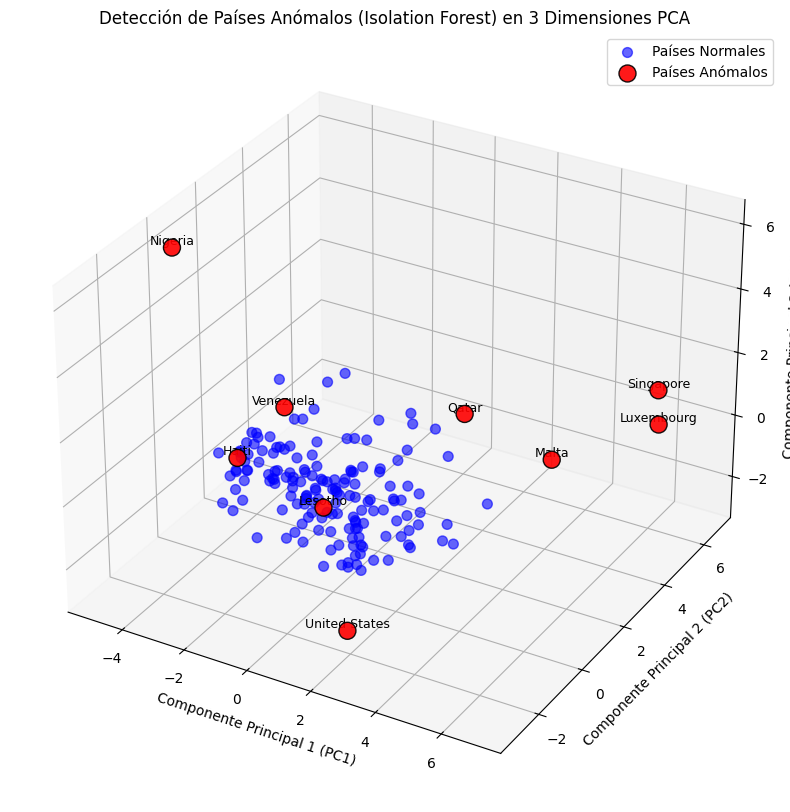


Países identificados como anómalos:
['Haiti', 'Lesotho', 'Luxembourg', 'Malta', 'Nigeria', 'Qatar', 'Singapore', 'United States', 'Venezuela']


In [149]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

pca_3_components = PCA(n_components=3)
X_reduced_for_clustering = pca_3_components.fit_transform(df_scaled)
X_reduced_for_clustering = pd.DataFrame(X_reduced_for_clustering, columns=["c1", "c2", "c3"])

iso_forest = IsolationForest(random_state=42, contamination=0.05)   #Contaminacion de 0.05
anomaly_labels = iso_forest.fit_predict(X_reduced_for_clustering[['c1', 'c2', 'c3']])

X_reduced_for_clustering['anomaly'] = anomaly_labels

X_reduced_for_clustering['country'] = df_original['country']

# Create the 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot inliers (label 1) and outliers (label -1) with different colors/markers
inliers = X_reduced_for_clustering[X_reduced_for_clustering['anomaly'] == 1]
outliers = X_reduced_for_clustering[X_reduced_for_clustering['anomaly'] == -1]

ax.scatter(
    inliers['c1'], inliers['c2'], inliers['c3'],
    label='Países Normales', s=50, alpha=0.6, c='blue'
)
ax.scatter(
    outliers['c1'], outliers['c2'], outliers['c3'],
    label='Países Anómalos', s=150, alpha=0.9, c='red', marker='o', edgecolors='black'
)

for i, row in outliers.iterrows():
    ax.text(row['c1'], row['c2'], row['c3'], row['country'], color='black', fontsize=9, ha='center', va='bottom')

ax.set_title('Detección de Países Anómalos (Isolation Forest) en 3 Dimensiones PCA')
ax.set_xlabel('Componente Principal 1 (PC1)')
ax.set_ylabel('Componente Principal 2 (PC2)')
ax.set_zlabel('Componente Principal 3 (PC3)')
ax.legend()
plt.grid(True)
plt.show()

anomalous_countries = outliers['country'].tolist()
print("\nPaíses identificados como anómalos:")
print(anomalous_countries)